In [5]:
import os 
from dotenv import load_dotenv

from datasets import load_from_disk, load_dataset
import numpy as np
import matplotlib.pyplot as plt 
import scienceplots 

plt.style.use("science")

load_dotenv() 

DATA_ROOT = os.getenv("DATA_ROOT")

model_no = "7361682_0"
fp = f"{DATA_ROOT}/hsc_embeddings/hsc_conditional_flow/embeddings/{model_no}"


data_files = {
    "train": f"{fp}/train/*.parquet",
    "val": f"{fp}/val/*.parquet",
    "test": f"{fp}/test/*.parquet"
}
ds_hsc_embeddings = load_dataset(
    "parquet",
    data_files=data_files
)

Generating train split: 179929 examples [00:05, 31583.99 examples/s]
Generating val split: 36102 examples [00:01, 25215.07 examples/s]
Generating test split: 36093 examples [00:00, 38177.03 examples/s]


In [6]:
ds_hsc_embeddings["test"]

Dataset({
    features: ['orig', 'cond', 'uncond'],
    num_rows: 36093
})

In [7]:
from scipy.stats import norm

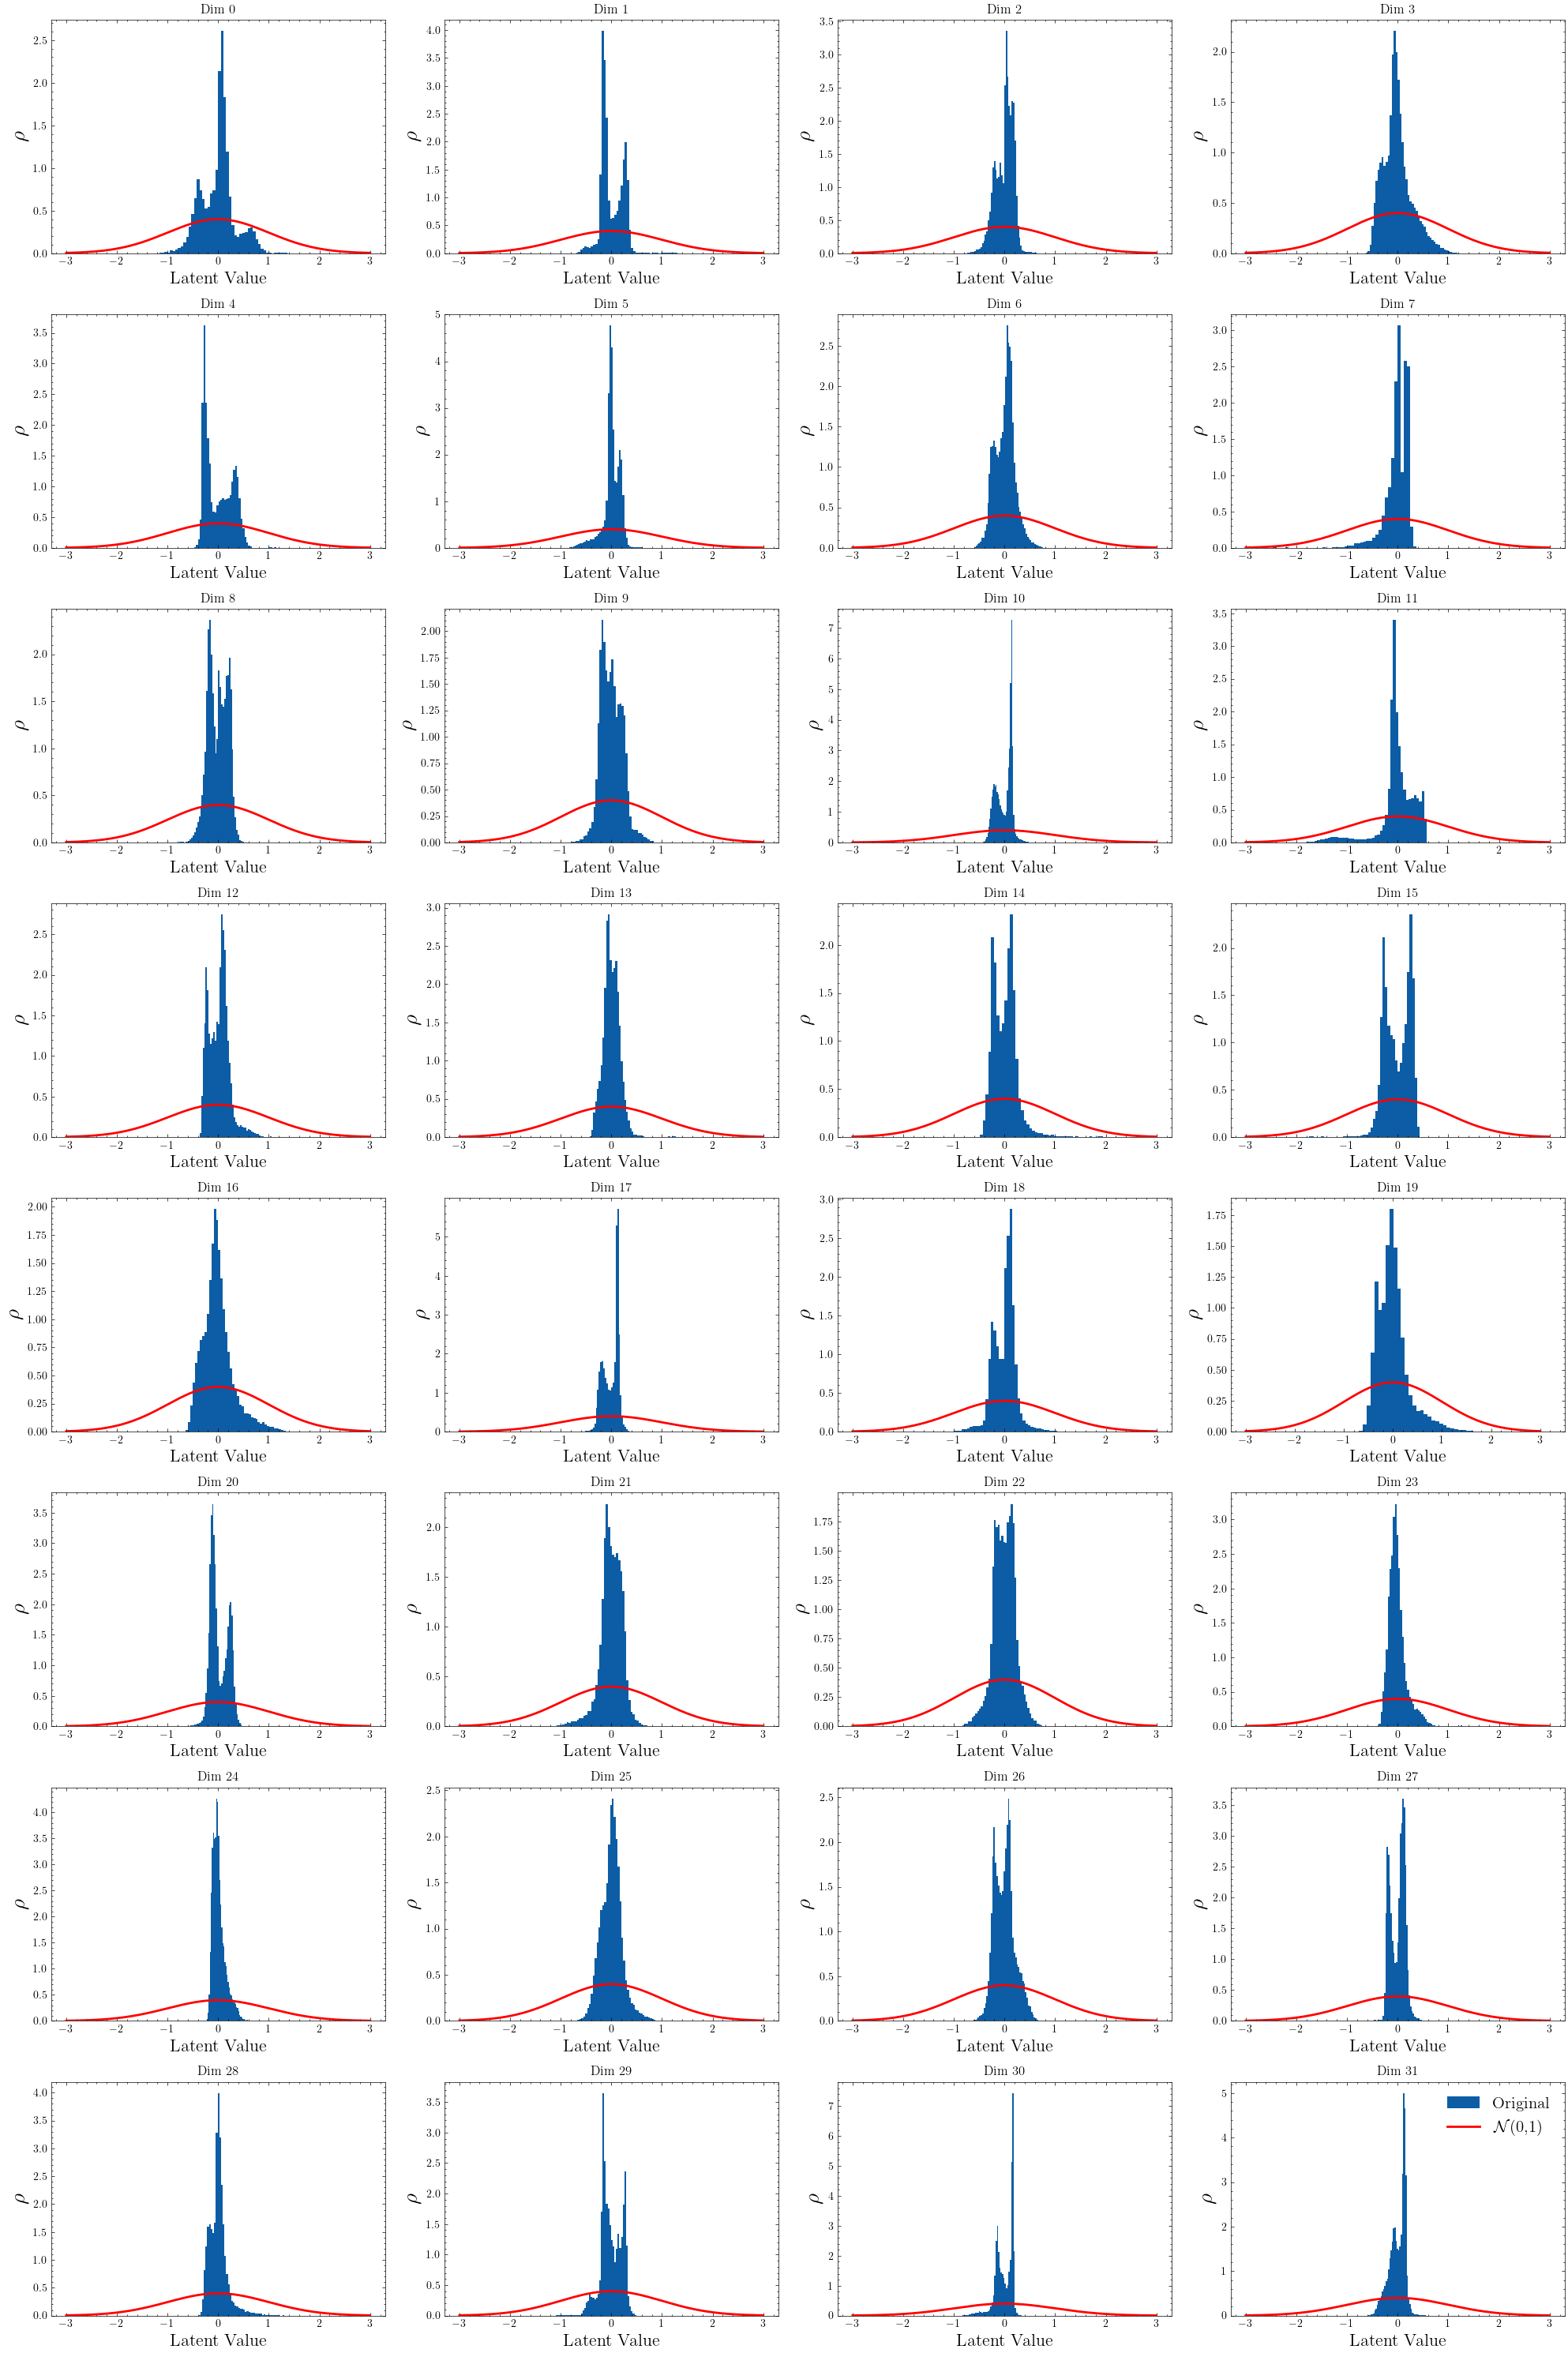

In [10]:
h = np.array(ds_hsc_embeddings["test"]["orig"])

N, D = h.shape

fig, axes = plt.subplots(8,4, figsize=(20, 30))
axes = axes.flatten()  # make indexing easier

x = np.linspace(-3, 3, 500)  # range for Gaussian

for i in range(D):
    axes[i].hist(h[:, i], bins=50, density=True, label="Original")
    axes[i].plot(x, norm.pdf(x, 0, 1), 'r-', lw=2, label=r'$\mathcal{N}$(0,1)')
    axes[i].set_title(f"Dim {i}")
    axes[i].set_xlabel("Latent Value", fontsize=16)
    axes[i].set_ylabel(r"$\rho$", fontsize=20)

plt.tight_layout()
plt.legend(fontsize=15)
plt.show()

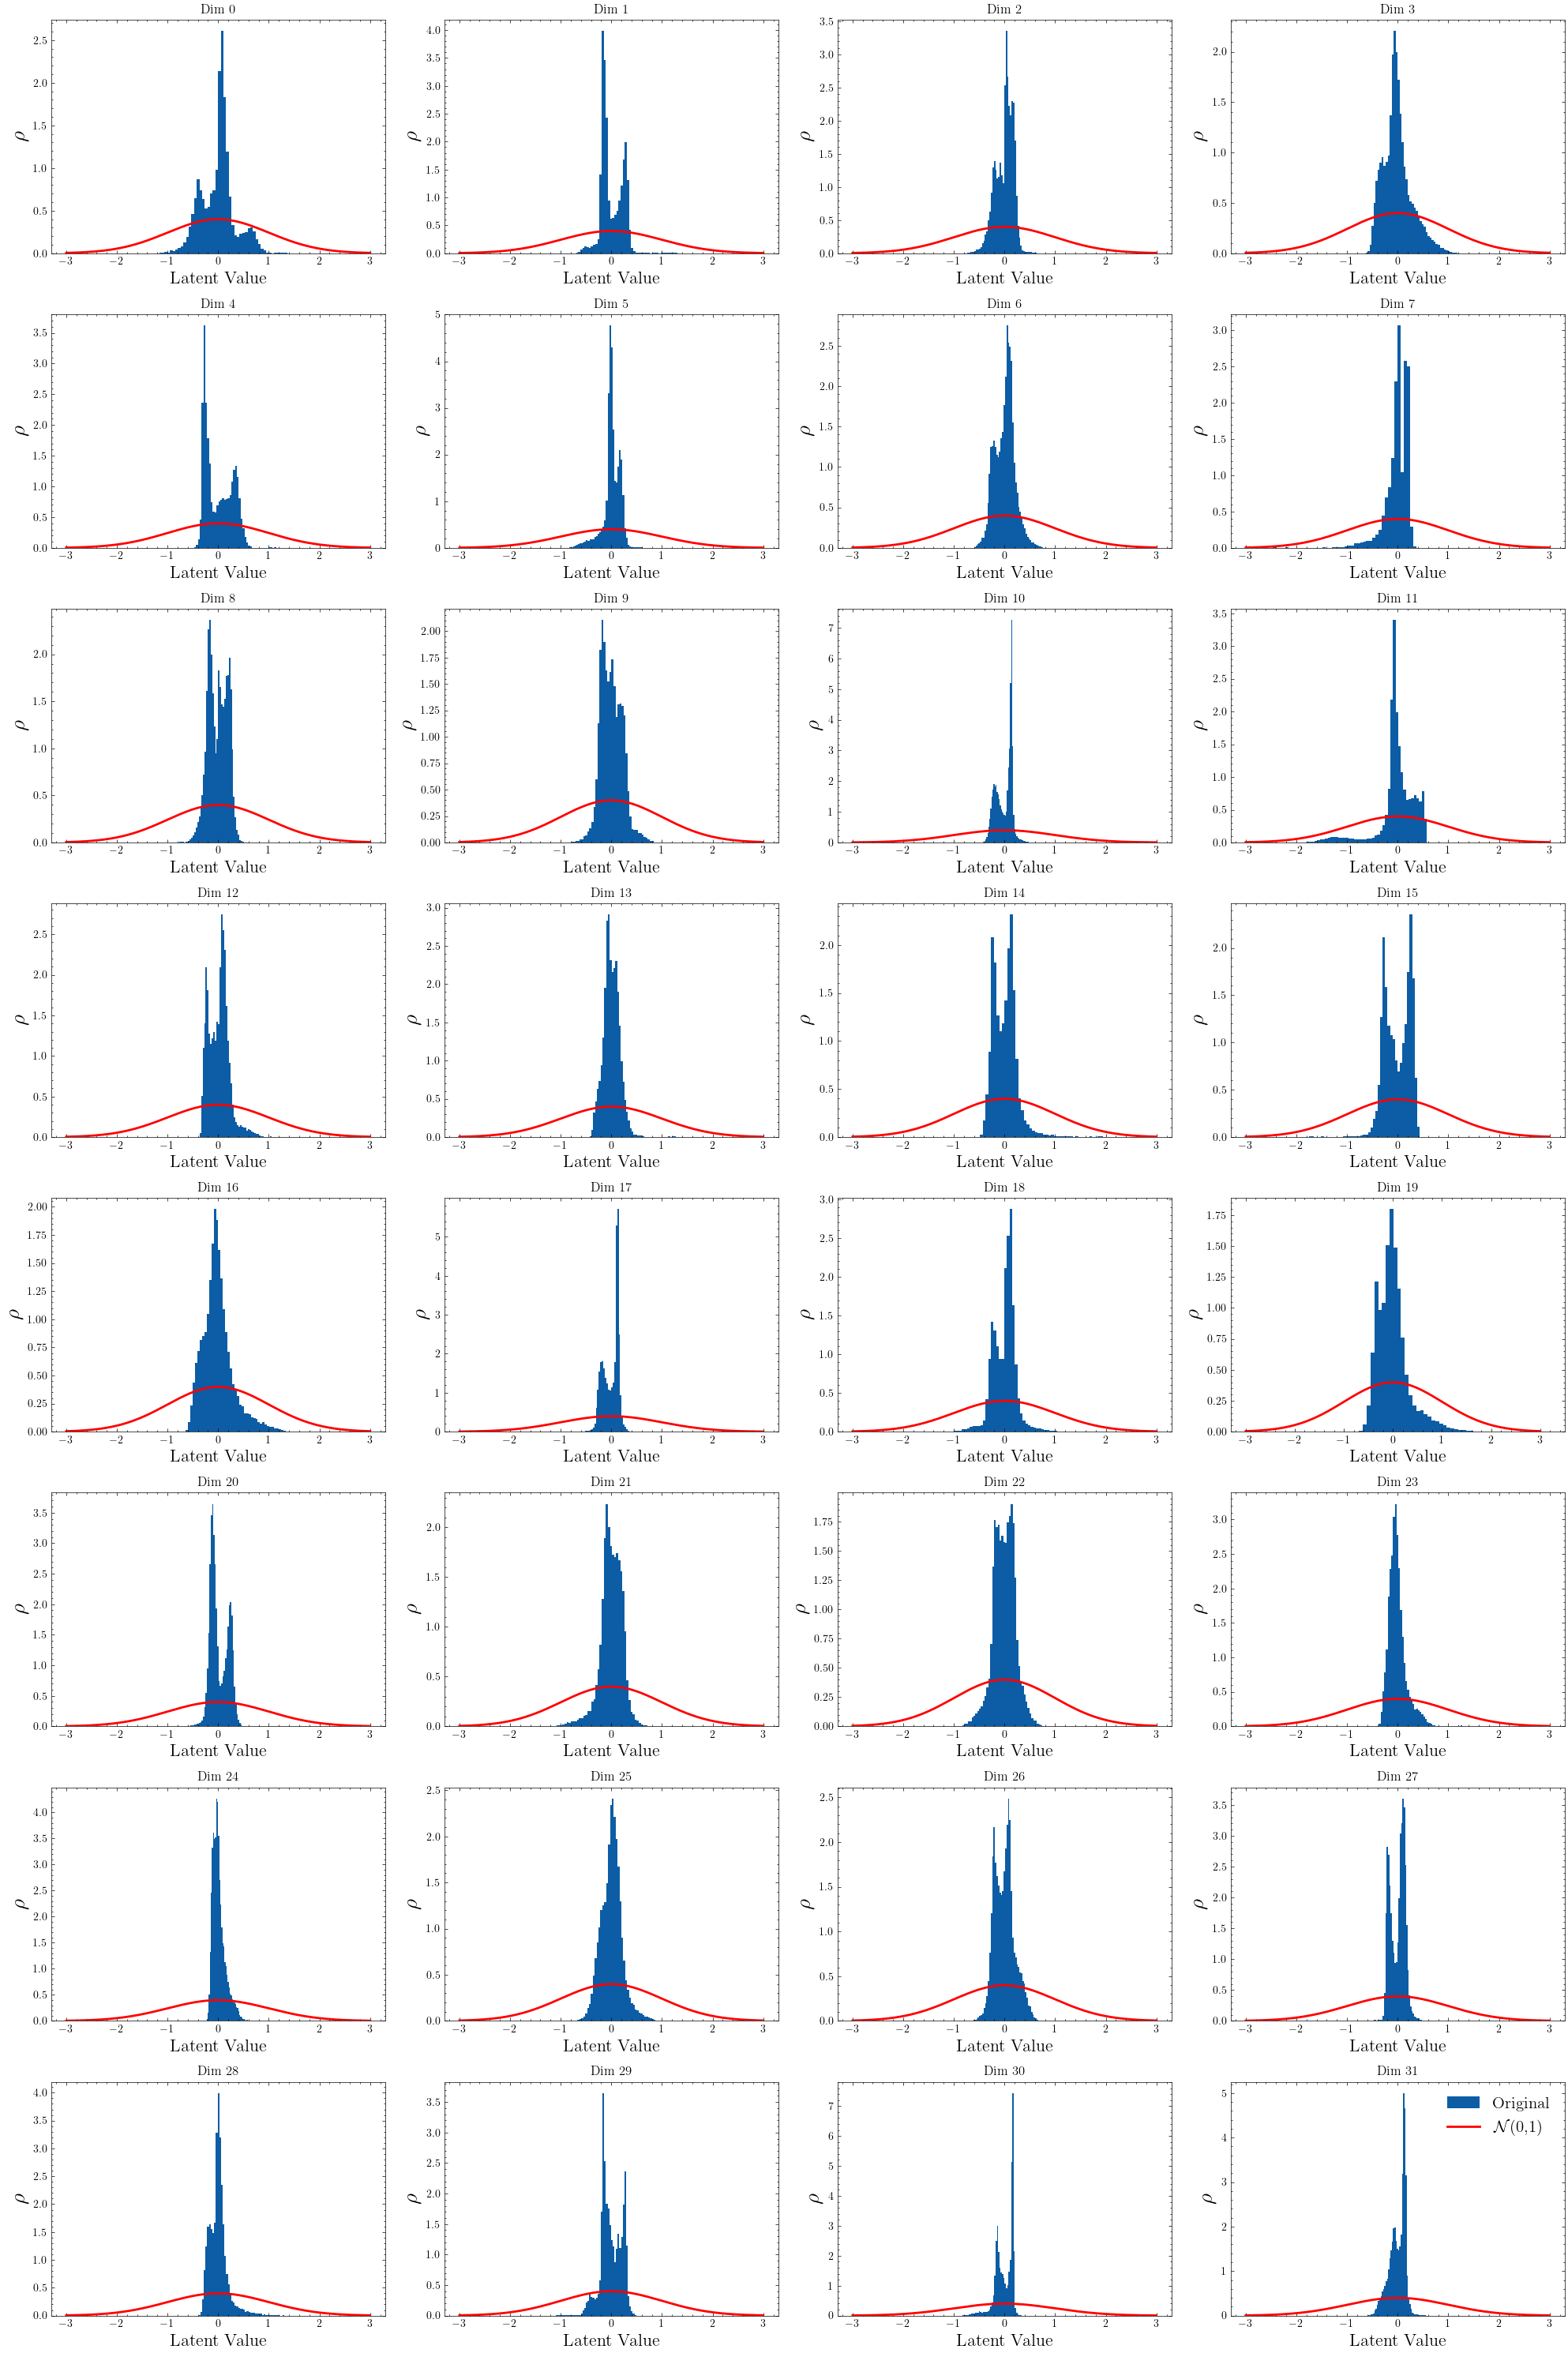

In [20]:
h = np.array(ds_hsc_embeddings["test"]["uncond"])

N, D = h.shape

fig, axes = plt.subplots(8,4, figsize=(20, 30))
axes = axes.flatten()  # make indexing easier

x = np.linspace(-3, 3, 500)  # range for Gaussian

for i in range(D):
    axes[i].hist(h[:, i], bins=50, density=True, label="Original")
    axes[i].plot(x, norm.pdf(x, 0, 1), 'r-', lw=2, label=r'$\mathcal{N}$(0,1)')
    axes[i].set_title(f"Dim {i}")
    axes[i].set_xlabel("Latent Value", fontsize=16)
    axes[i].set_ylabel(r"$\rho$", fontsize=20)

plt.tight_layout()
plt.legend(fontsize=15)
plt.show()

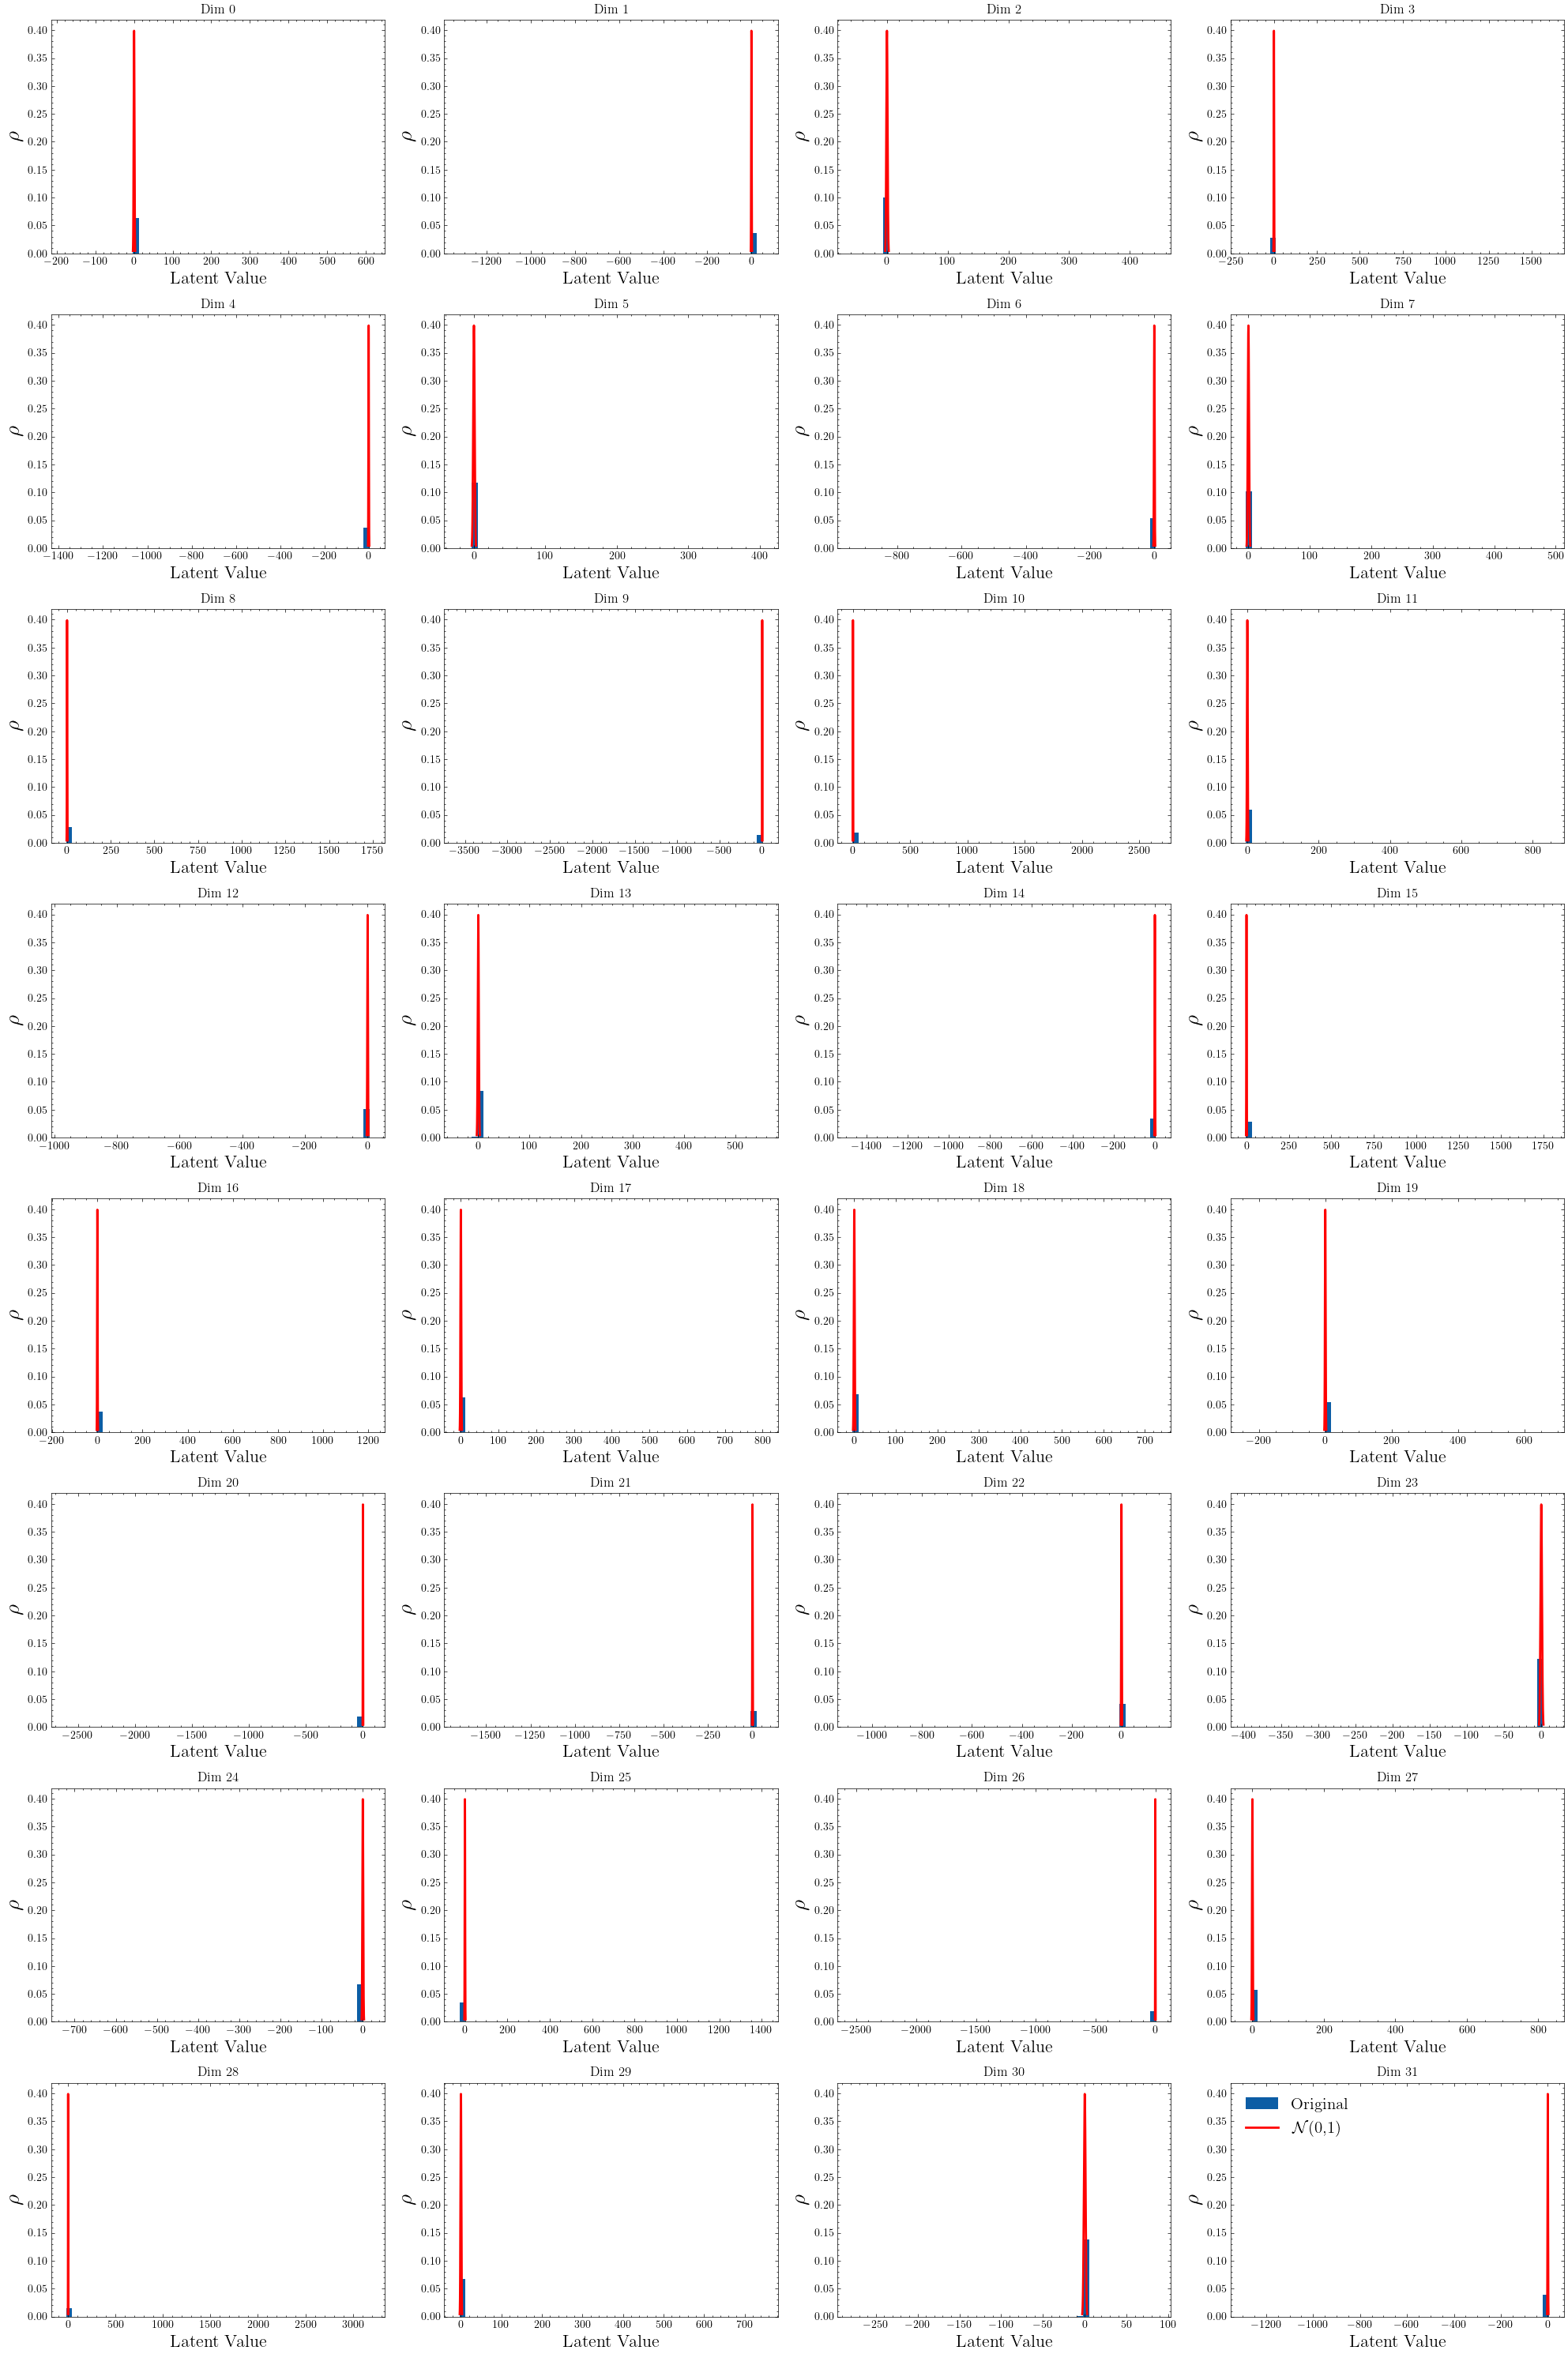

In [21]:
h = np.array(ds_hsc_embeddings["test"]["cond"])

N, D = h.shape

fig, axes = plt.subplots(8,4, figsize=(20, 30))
axes = axes.flatten()  # make indexing easier

x = np.linspace(-3, 3, 500)  # range for Gaussian

for i in range(D):
    axes[i].hist(h[:, i], bins=50, density=True, label="Original")
    axes[i].plot(x, norm.pdf(x, 0, 1), 'r-', lw=2, label=r'$\mathcal{N}$(0,1)')
    axes[i].set_title(f"Dim {i}")
    axes[i].set_xlabel("Latent Value", fontsize=16)
    axes[i].set_ylabel(r"$\rho$", fontsize=20)

plt.tight_layout()
plt.legend(fontsize=15)
plt.show()